###AIRO Linear Regression Example
Student Study Hours vs Exam Grade

Created by Caden Wondell

Step 1: Mount to Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Step 2: Import Required Libraries

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

Step 3: Load and Preview the Dataset

In [ ]:
data = pd.read_csv(
    "/content/drive/MyDrive/Colab_Notebooks/AIRO_CLUB/Examples/Exam_Score_Prediction.csv"
)
data.head()

,student_id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,1,17,male,diploma,2.78,92.9,yes,7.4,poor,coaching,low,hard,58.9
1,2,23,other,bca,3.37,64.8,yes,4.6,average,online videos,medium,moderate,54.8
2,3,22,male,b.sc,7.88,76.8,yes,8.5,poor,coaching,high,moderate,90.3
3,4,20,other,diploma,0.67,48.4,yes,5.8,average,online videos,low,moderate,29.7
4,5,20,female,diploma,0.89,71.6,yes,9.8,poor,coaching,low,moderate,43.7


Step 4: Select the Feature and Target

In [ ]:
# Feature: what we give the model
X = data[["study_hours"]]

# Target: what we want the model to predict
y = data["exam_score"]

Step 5: Split the Data into Training and Testing Sets

In [ ]:
#Split data into Training and Testing datasets, Training is 80%, Testing is 20%
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Step 6: Create and Train the Linear Regression Model

In [ ]:
model = LinearRegression() #Create the Model

model.fit(X_train, y_train) #Train the model

LinearRegression()

Step 7: Make Predictions

In [ ]:
predictions = model.predict(X_test) #Make predictions

predictions[:5] #Show the first 5 predictions

array([50.81187609, 77.50565809, 64.07076561, 81.72972909, 80.8497143 ])

Step 8: Compare Predicted and Actual Scores

In [ ]:
results = pd.DataFrame({
    "Study Hours": X_test["study_hours"],
    "Actual Score": y_test,
    "Predicted Score": predictions
})

results.head(10) #Compare Predictions vs Real scores

,Study Hours,Actual Score,Predicted Score
10650,2.01,31.1,50.811876
2041,6.56,81.6,77.505658
8668,4.27,68.0,64.070766
1114,7.28,100.0,81.729729
13902,7.13,84.8,80.849714
11963,0.78,52.8,43.595755
11072,4.45,53.1,65.126783
3002,5.53,81.0,71.462890
19771,3.54,72.6,59.788027
8115,0.33,25.4,40.955710


Step 9: Evaluate the Model

In [ ]:
mae = mean_absolute_error(y_test, predictions)

print("Mean Absolute Error:", round(mae, 2)) #The lower the score the better the prediction

Mean Absolute Error: 10.64


Step 10: Visualize the Linear Regression Model

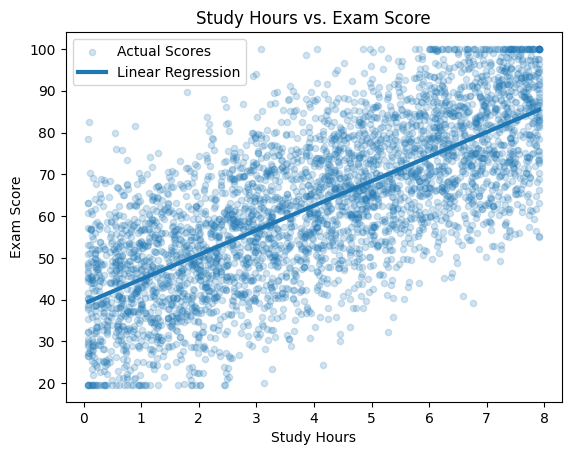

In [ ]:
# Sort the values so the regression line is drawn correctly
X_line = X_test.sort_values("study_hours")
y_line = model.predict(X_line)

plt.scatter(
    X_test["study_hours"],
    y_test,
    alpha=0.2,
    s=20,
    label="Actual Scores"
)

plt.plot(
    X_line["study_hours"],
    y_line,
    linewidth=3,
    label="Linear Regression"
)

plt.xlabel("Study Hours")
plt.ylabel("Exam Score")
plt.title("Study Hours vs. Exam Score")
plt.legend()

plt.show()

Step 11: Make a Prediction for a New Student

In [ ]:
new_student = pd.DataFrame({
    "study_hours": [10]
})

predicted_score = model.predict(new_student)

print("Study Hours:", new_student["study_hours"][0])
print("Predicted Exam Score:", round(predicted_score[0], 2))

Study Hours: 10
Predicted Exam Score: 97.69
